<a href="https://colab.research.google.com/github/suryaniteesh230-debug/ml/blob/main/Untitled20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import tensorflow as tf
tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=False, name="SGD")

In [19]:
from matplotlib import pyplot as plt

# Fixed points for plotting
w = [-2, -1, 0, 1, 2, 3, 4]
l = [4, 1, 0, 1, 4, 9, 16]

# Gradient
slope = 2 * w

# Starting point
start = -1

# Momentum parameters
beta = 0.9
n = 0.01

# Arrays to store history
v = []
w_c = [start]


for i in range(10):

    # Previous velocity
    if i == 0:
        v_prev = 0
    else:
        v_prev = v[i-1]

    # Current weight
    w_prev = w_c[i]

    # Gradient at current weight
    delw = 2 * w_prev

    # Momentum equation
    v_new = beta * v_prev + n * delw

    # Weight update
    w_new = w_prev - v_new

    # Store values
    v.append(v_new)
    w_c.append(w_new)


print("Velocity:", v)
print("Weights:", w_c)

Velocity: [-0.02, -0.0376, -0.052688, -0.06521344000000001, -0.07518206720000001, -0.082650190336, -0.08771849735168001, -0.09052560371875842, -0.09124148737475382, -0.09006095291765459]
Weights: [-1, -0.98, -0.9424, -0.8897120000000001, -0.8244985600000001, -0.7493164928000001, -0.6666663024640002, -0.5789478051123201, -0.48842220139356174, -0.39718071401880795, -0.30711976110115335]


In [20]:
import numpy as np
import pandas as pd

df=pd.read_csv("diabetes.csv")
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [21]:
x=df.iloc[:,0:8]
y=df.iloc[:,8]
import tensorflow as tf
from tensorflow import keras


In [22]:
df.corr()['Outcome']

,Outcome
Pregnancies,0.221898
Glucose,0.466581
BloodPressure,0.065068
SkinThickness,0.074752
Insulin,0.130548
BMI,0.292695
DiabetesPedigreeFunction,0.173844
Age,0.238356
Outcome,1.000000


In [23]:
c=df.corr()['Outcome']
df=df.loc[:,abs(c)>0.2]
df

,Pregnancies,Glucose,BMI,Age,Outcome
0,6,148,33.6,50,1
1,1,85,26.6,31,0
2,8,183,23.3,32,1
3,1,89,28.1,21,0
4,0,137,43.1,33,1
...,...,...,...,...,...
763,10,101,32.9,63,0
764,2,122,36.8,27,0
765,5,121,26.2,30,0
766,1,126,30.1,47,1


In [24]:
X=df.iloc[:,:-1].values
y=df.iloc[:,-1].values

In [25]:
from sklearn.preprocessing import StandardScaler
s=StandardScaler()


In [26]:
X=s.fit_transform(X)


In [27]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [61]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense,Dropout

In [29]:
model=Sequential()
model.add(Dense(32,activation="sigmoid",input_dim=4))
model.add(Dense(16,activation='sigmoid'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5798 - loss: 0.6765 - precision: 0.3333 - val_accuracy: 0.6429 - val_loss: 0.6562 - val_precision: 0.0000e+00
Epoch 2/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6531 - loss: 0.6390 - precision: 0.0000e+00 - val_accuracy: 0.6429 - val_loss: 0.6431 - val_precision: 0.0000e+00
Epoch 3/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6531 - loss: 0.6323 - precision: 0.0000e+00 - val_accuracy: 0.6429 - val_loss: 0.6384 - val_precision: 0.0000e+00
Epoch 4/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6531 - loss: 0.6248 - precision: 0.0000e+00 - val_accuracy: 0.6429 - val_loss: 0.6309 - val_precision: 0.0000e+00
Epoch 5/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6531 - loss: 0.6182 - precision: 0.0000e+00 - val_accuracy: 0.6429 - val_loss: 0.6234 - val_precision: 0.0000e+00
Epoch 6/60
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6531 - loss: 0.6097 - precision: 0.0000e+00 - val

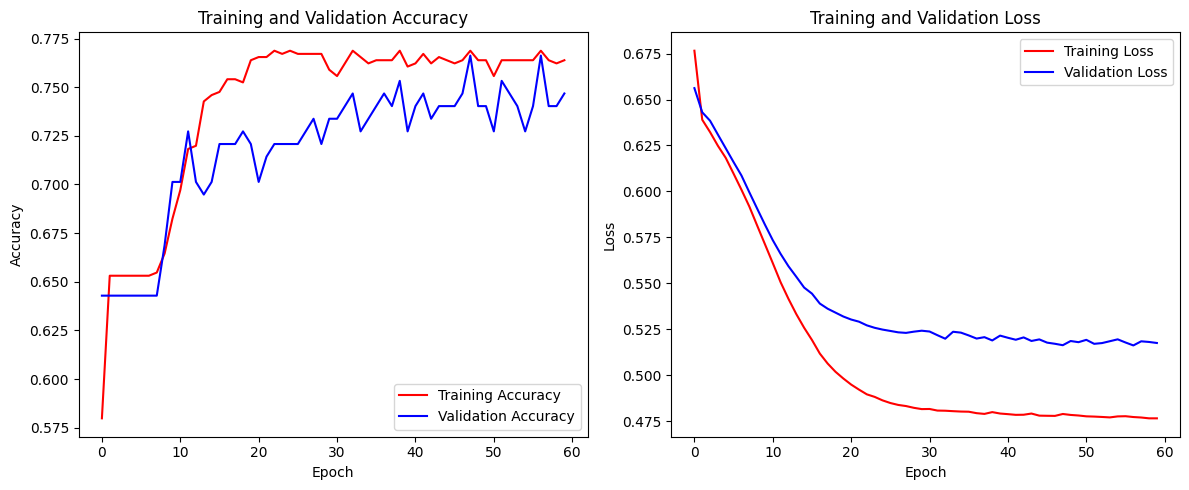

In [30]:
from keras.src.optimizers import Adam
model.compile(loss="binary_crossentropy",optimizer="Adam",metrics=["accuracy","precision"])
history=model.fit(X_train,y_train,batch_size=32,epochs=60,validation_data=(X_test,y_test))

from matplotlib import pyplot as plt

# Plot accuracy and validation accuracy
plt.figure(figsize=(12, 5)) # Create a new figure for better separation
plt.subplot(1, 2, 1) # First subplot
plt.plot(history.history['accuracy'], color='red', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], color='blue', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss and validation loss
plt.subplot(1, 2, 2) # Second subplot
plt.plot(history.history['loss'], color='red', label='Training Loss')
plt.plot(history.history['val_loss'], color='blue', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # Adjust layout to prevent overlapping
plt.show() # Display the plots

In [31]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,117 (8.27 KB)

 Trainable params: 705 (2.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,412 (5.52 KB)

In [32]:
#how to select optimizer
#no ofnodes in a layer
#no of hidden layers
!pip install -q -U keras-tuner

In [33]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
model=Sequential()

In [34]:
import keras_tuner as kt


In [35]:
#optimizer:
#hp-hyperparameter
def build_model(hp):
  model=Sequential()
  model.add(Dense(32,activation="relu",input_dim=4))
  model.add(Dense(16,activation="relu"))
  model.add(Dense(1,activation="sigmoid"))

  optimizer=hp.Choice('optimizer',values=['adam','sgd','rmsprop','adadelta','nadam'])
  model.compile(optimizer=optimizer,loss='binary_crossentropy',metrics=['accuracy'])

  return model



In [36]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5
)

In [37]:
tuner.search(X_train,y_train,epochs=5,validation_data=(X_test,y_test))


Trial 5 Complete [00h 00m 03s]
val_accuracy: 0.7272727489471436

Best val_accuracy So Far: 0.7792207598686218
Total elapsed time: 00h 00m 26s


In [38]:
tuner.get_best_hyperparameters()[0].values

{'optimizer': 'rmsprop'}

In [39]:
model=tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 8 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [40]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 705 (2.75 KB)

 Trainable params: 705 (2.75 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
model.fit(X_train,y_train,batch_size=32,epochs=100,initial_epoch=6,validation_data=(X_test,y_test))

Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7704 - loss: 0.4839 - val_accuracy: 0.7792 - val_loss: 0.5045
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7687 - loss: 0.4745 - val_accuracy: 0.7792 - val_loss: 0.5033
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7752 - loss: 0.4708 - val_accuracy: 0.7857 - val_loss: 0.5021
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7704 - loss: 0.4685 - val_accuracy: 0.7792 - val_loss: 0.5024
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7736 - loss: 0.4666 - val_accuracy: 0.7857 - val_loss: 0.5025
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7752 - loss: 0.4652 - val_accuracy: 0.7792 - val_loss: 0.5019
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7736 - loss: 0.4639 - val_accuracy: 0.7857 - val_loss: 0.5043
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7736 - loss: 0.4630 - val_accuracy

In [42]:
def build_model(hp):
  model=Sequential()
  units=hp.Int("units",8,200,step=10)
  model.add(Dense(units=units,activation="relu",input_dim=4))
  model.add(Dense(units=units,activation="relu"))
  model.add(Dense(1,activation="sigmoid"))

  model.compile(optimizer="sgd",loss="binary_crossentropy",metrics=["accuracy"])
  return model

In [43]:
tuner=kt.RandomSearch(build_model,
                      objective="val_accuracy",
                      max_trials=5,
                      directory="mydir",
                      project_name="myfile"
                      )

In [44]:
tuner.search(X_train,y_train,epochs=4,validation_data=[X_test,y_test])

Trial 5 Complete [00h 00m 02s]
val_accuracy: 0.6883116960525513

Best val_accuracy So Far: 0.7662337422370911
Total elapsed time: 00h 00m 11s


In [45]:
tuner.get_best_hyperparameters()[0].values

{'units': 128}

In [46]:
model=tuner.get_best_models(num_models=1)[0]

In [47]:
model.fit(X_train,y_train,batch_size=32,epochs=100,initial_epoch=5)

Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7443 - loss: 0.6388  
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7590 - loss: 0.6180 
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7557 - loss: 0.6006 
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7573 - loss: 0.5857 
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7524 - loss: 0.5719 
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7541 - loss: 0.5602 
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7606 - loss: 0.5494 
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7606 - loss: 0.5402 
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7622 - loss: 0.5321
Epoch 15/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7590 - loss: 0.5250
Epoch 16/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7590 - loss: 0.5184
Epoch 17/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/st

In [48]:
def build_model(hp):
  model=Sequential()
  model.add(Dense(88,activation="relu",input_dim=4))
  for i in range(hp.Int('num_layers',min_value=1,max_value=10)):
    model.add(Dense(88,activation="relu"))
  model.add(Dense(1,activation="sigmoid"))
  model.compile(optimizer="sgd",loss='binary_crossentropy',metrics=["accuracy"])
  return model

In [49]:
tuner=kt.RandomSearch(build_model,
                      objective='val_accuracy',
                      max_trials=3,
                      directory="mydir",
                      project_name="numlayers")

In [50]:
tuner.search(X_train,y_train,epochs=5,validation_data=(X_test,y_test))

Trial 3 Complete [00h 00m 06s]
val_accuracy: 0.6428571343421936

Best val_accuracy So Far: 0.7207792401313782
Total elapsed time: 00h 00m 17s


In [51]:
model=tuner.get_best_models(num_models=1)[0]

In [52]:
model.fit(X_train,y_train,batch_size=32,epochs=100,initial_epoch=6,validation_data=(X_test,y_test))

Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7101 - loss: 0.6729 - val_accuracy: 0.6558 - val_loss: 0.6683
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6678 - loss: 0.6603 - val_accuracy: 0.6364 - val_loss: 0.6600
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6645 - loss: 0.6508 - val_accuracy: 0.6494 - val_loss: 0.6523
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6612 - loss: 0.6420 - val_accuracy: 0.6494 - val_loss: 0.6448
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6596 - loss: 0.6333 - val_accuracy: 0.6494 - val_loss: 0.6380
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6596 - loss: 0.6251 - val_accuracy: 0.6494 - val_loss: 0.6315
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6596 - loss: 0.6173 - val_accuracy: 0.6494 - val_loss: 0.6254
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6612 - loss: 0.6096 - val_accuracy: 0.63

KeyboardInterrupt: 

In [69]:
def build_model(hp):
  model=Sequential()

  counter=0

  for i in range(hp.Int('num_layers',min_value=1,max_value=10)):
    if counter==0:
      model.add(Dense(
          hp.Int("units"+str(i),min_value=8,max_value=128,step=8),
          activation=hp.Choice("activation"+str(i),values=["relu",'sigmoid','elu','tanh']),
          input_dim=4)
      )
      model.add(Dropout(hp.Choice("dropout"+str(i),values=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])))
    else:
      model.add(Dense(
          hp.Int("units"+str(i),min_value=8,max_value=128,step=10),
          activation=hp.Choice("actvation"+str(i),values=['sigmoid','relu','tanh'])
      ))
      model.add(Dropout(hp.Choice("droput"+str(i),values=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])))
    counter+=1
    model.add(Dense(1,activation='sigmoid'))
    model.compile(optimizer=hp.Choice("optimizer",values=['rmsprop','adagrad','sdg']),loss=hp.Choice("loss",values=['binary_crossentropy','mse']),metrics=['accuracy'])

    return model


In [70]:
tuner=kt.RandomSearch(build_model,
                      objective='val_accuracy',
                      max_trials=3,
                      directory='mydir',
                      project_name='myproj1')


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [71]:
tuner.search(
    X_train,y_train,
    epochs=5,
    validation_data=(X_test,y_test)
)

Trial 3 Complete [00h 00m 01s]

Best val_accuracy So Far: 0.3571428656578064
Total elapsed time: 00h 00m 06s


In [56]:
tuner.get_best_hyperparameters()[0].values

{'num_layers': 1,
 'units0': 104,
 'activation0': 'sigmoid',
 'optimizer': 'rmsprop',
 'loss': 'binary_crossentropy'}

In [72]:
model=tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adagrad', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [73]:
model.fit(X_train,y_train,epochs=100,initial_epoch=6,validation_data=(X_test,y_test))

Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4967 - loss: 0.7500 - val_accuracy: 0.4481 - val_loss: 0.7233
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4935 - loss: 0.7552 - val_accuracy: 0.4935 - val_loss: 0.7100
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4642 - loss: 0.7551 - val_accuracy: 0.5649 - val_loss: 0.6986
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5603 - loss: 0.7159 - val_accuracy: 0.5779 - val_loss: 0.6895
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5505 - loss: 0.6998 - val_accuracy: 0.6039 - val_loss: 0.6814
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5765 - loss: 0.6809 - val_accuracy: 0.6104 - val_loss: 0.6742
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5831 - loss: 0.6952 - val_accuracy: 0.6039 - val_loss: 0.6683
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5912 - loss: 0.6932 - val_accuracy: 0.61